In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
import os

In [10]:
base_dir = os.getcwd()
gdx_path = os.path.join(base_dir, "data", "futures", "adjusted_prices_csv", "GDX.csv")
gld_path = os.path.join(base_dir, "data", "futures", "adjusted_prices_csv", "GLD.csv")

In [11]:
gdx = pd.read_csv(gdx_path)
gld = pd.read_csv(gld_path)
#gdx = pd.read_csv(r'D:\Trading\simple_trading_system\data\futures\adjusted_prices_csv\GDX.csv')
#gld = pd.read_csv(r'D:\Trading\simple_trading_system\data\futures\adjusted_prices_csv\GLD.csv')

In [ ]:
gdx = gdx[['Date', 'Adj Close']]
gld = gld[['Date', 'Adj Close']]

,Date,Adj Close
0,"Jun 5, 2025",53.25
1,"Jun 4, 2025",53.21
2,"Jun 3, 2025",53.09
3,"Jun 2, 2025",53.77
4,"May 30, 2025",50.65


In [14]:
gdx.dropna(inplace=True)
gld.dropna(inplace=True)
gld['Date'] = pd.to_datetime(gld['Date'])
gdx['Date'] = pd.to_datetime(gdx['Date'])
prices = pd.merge(gld, gdx, on='Date', how='inner')
prices.rename(columns={'Adj Close_x': 'GLD', 'Adj Close_y': 'GDX'}, inplace=True)
prices.sort_values(by='Date', inplace=True)

In [15]:
model = RollingOLS(prices['GLD'], sm.add_constant(prices['GDX']), window=200)
results = model.fit()
prices['hedge_ratio'] = results.params['GDX']
prices['spread'] = prices['GLD'] - prices['hedge_ratio'] * prices['GDX']
prices['spread_mean'] = prices['spread'].rolling(200).mean()
prices['spread_std'] = prices['spread'].rolling(200).std()
prices['z_score'] = (prices['spread'] - prices['spread_mean']) / prices['spread_std']

In [ ]:
prices

,Date,GLD,GDX,hedge_ratio,spread,spread_mean,spread_std,z_score
4790,2006-05-22,65.30,31.82,NaN,NaN,NaN,NaN,NaN
4789,2006-05-23,66.38,32.45,NaN,NaN,NaN,NaN,NaN
4788,2006-05-24,64.06,31.22,NaN,NaN,NaN,NaN,NaN
4787,2006-05-25,64.70,32.76,NaN,NaN,NaN,NaN,NaN
4786,2006-05-26,65.10,32.95,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
4,2025-05-30,303.60,50.65,4.805788,60.186846,81.214678,13.186226,-1.594682
3,2025-06-02,311.67,53.77,4.762177,55.607764,81.117870,13.302864,-1.917640
2,2025-06-03,308.91,53.09,4.722443,58.195482,81.037119,13.392892,-1.705504
1,2025-06-04,310.90,53.21,4.688471,61.426453,80.972141,13.456521,-1.452507


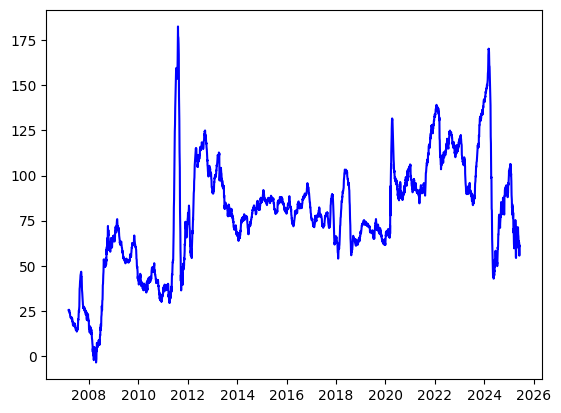

In [17]:
plt.plot(prices['Date'], prices['spread'], label='Spread', color='blue')

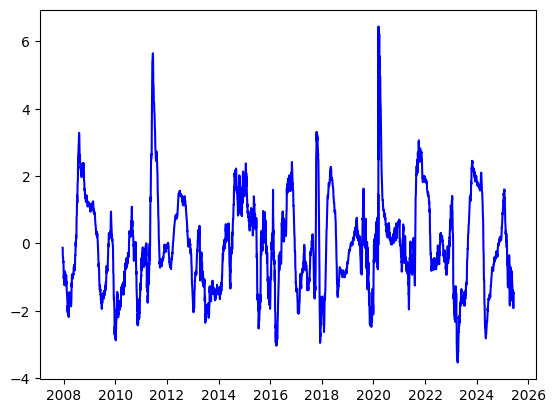

In [18]:
plt.plot(prices['Date'], prices['z_score'], label='Spread', color='blue')

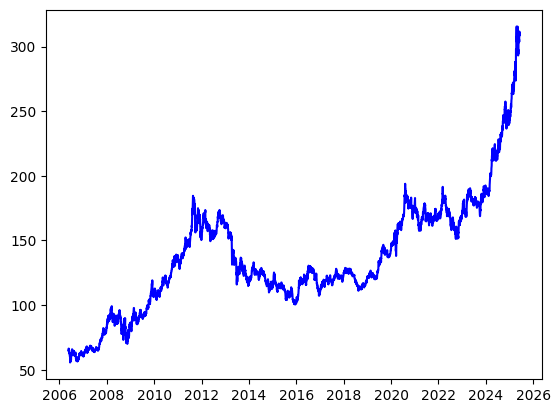

In [19]:
plt.plot(prices['Date'], prices['GLD'], label='Spread', color='blue')

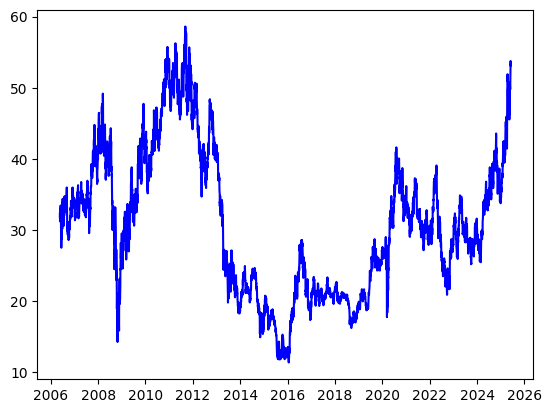

In [20]:
plt.plot(prices['Date'], prices['GDX'], label='Spread', color='blue')

In [ ]:
""" Calculate P&L at one time point using:
    position: (np) arrary [direction, GLD units, GDX units]
    previous_price: (pd) DataFrame with previous (yesturdays) prices
    current_price: (pd) DataFrame with current prices"""


def calculate_pandl(position, previous_price, current_price):
    if position == 1: # GLD long, GDX short
        long_pnl = (current_price['GLD'] - previous_price['GLD'])* position[1]
        short_pnl = (previous_price['GDX'] - current_price['GDX']) * position[2]
        return long_pnl + short_pnl
    elif position == -1:
        long_pnl = (previous_price['GLD'] - current_price['GLD']) * position[1]
        short_pnl = (current_price['GDX'] - previous_price['GDX']) * position[2]
        return long_pnl + short_pnl
    else:
        return 0

In [ ]:
def backtester(data, entry_threshold=2, exit_threshold=1):
    position = np.nan((len(data),4)) # position, GLD units, GDX units, PnL
    position[399,:] = np.array([0, 0, 0, 0])  # Initialize first position
    for i in range(400, len(data)-1):
        if data['z_score'].iloc[i] > entry_threshold:  
            if position[i-1,0] == -1:  # If already short
                position[i,:] = np.array([-1, position[i-1,1], position[i-1,2], position[i-1,3]])
            elif position[i-1,0] == 0:  # If flat
                position[i,:] = np.array([-1, -data['GLD'].iloc[i], data['hedge_ratio'].iloc[i] * data['GLD'].iloc[i], position[i-1,3]])
            else:  # If long
                pnl = position[i-1,3] + ()
                position[i,:] = np.array([-1])
            position[i,:] = 
    return position

,Position,GLD Units,GDX Units,PnL
0,0,0,0,0


In [88]:
prices

,Date,GLD,GDX,hedge_ratio,spread,spread_mean,spread_std,z_score
4790,2006-05-22,65.30,31.82,NaN,NaN,NaN,NaN,NaN
4789,2006-05-23,66.38,32.45,NaN,NaN,NaN,NaN,NaN
4788,2006-05-24,64.06,31.22,NaN,NaN,NaN,NaN,NaN
4787,2006-05-25,64.70,32.76,NaN,NaN,NaN,NaN,NaN
4786,2006-05-26,65.10,32.95,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
4,2025-05-30,303.60,50.65,4.805788,60.186846,81.214678,13.186226,-1.594682
3,2025-06-02,311.67,53.77,4.762177,55.607764,81.117870,13.302864,-1.917640
2,2025-06-03,308.91,53.09,4.722443,58.195482,81.037119,13.392892,-1.705504
1,2025-06-04,310.90,53.21,4.688471,61.426453,80.972141,13.456521,-1.452507
